In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [41]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_242_lrdata.h5ad")

In [42]:
lrdata.obs["typ"].value_counts()

typ
242_TVA    287351
242_CRC     90167
242_REF     44314
Name: count, dtype: int64

### DR and cluster

In [43]:
# 1) PCA
sc.tl.pca(lrdata, svd_solver="arpack", n_comps=50, random_state=0)

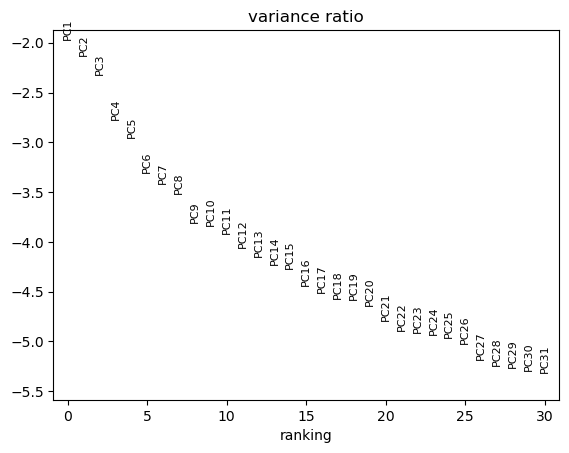

In [44]:
# PCA diagnostics (optional)
sc.pl.pca_variance_ratio(lrdata, log=True)          # elbow plot

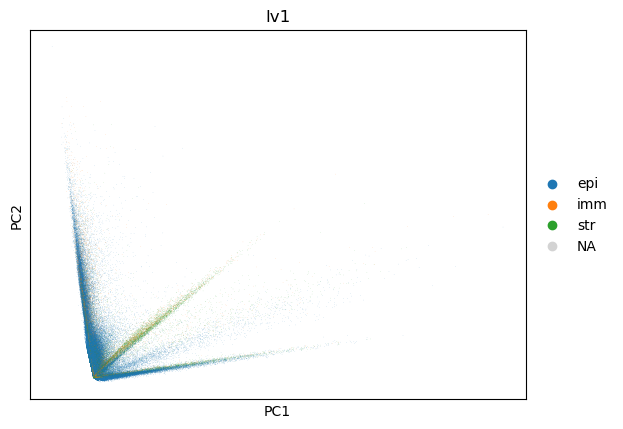

In [45]:
# Quick PCA scatter, colored by metadata (e.g., lv1) or anything in .obs
sc.pl.pca(lrdata, color=["lv1"], components="1,2")  # change color list as needed

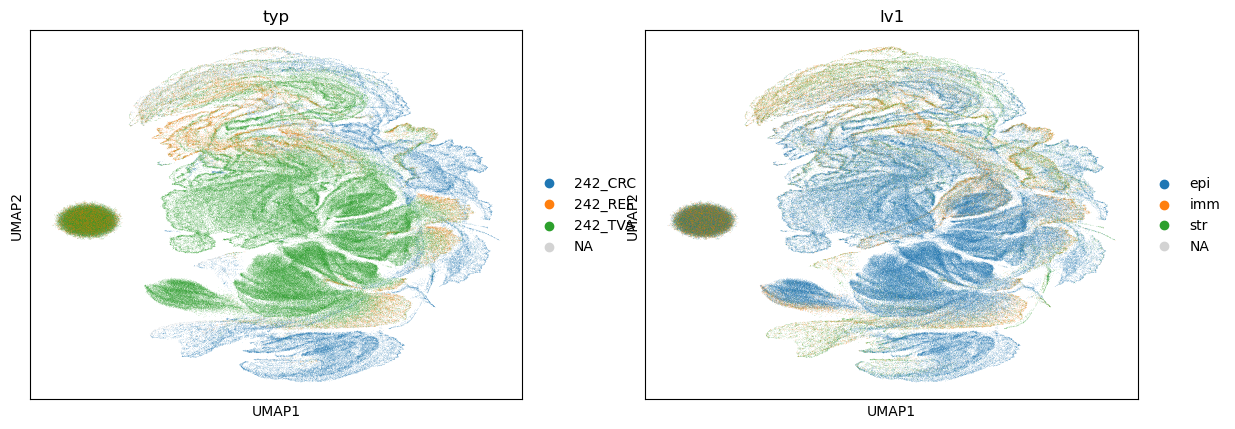

In [46]:
# 2) Neighborhood graph on PCA space
sc.pp.neighbors(lrdata, n_neighbors=15, n_pcs=25, metric="euclidean", random_state=0)

# 4) Low-dim embeddings (optional but handy to view clusters)
sc.tl.umap(lrdata, random_state=0)
sc.pl.umap(lrdata, color=["typ", "lv1"])

In [47]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [48]:
# Run HDBSCAN on the UMAP embedding
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
lrdata.obs['hdbscan'] = clusterer.fit_predict(lrdata.obsm['X_umap']).astype(str)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


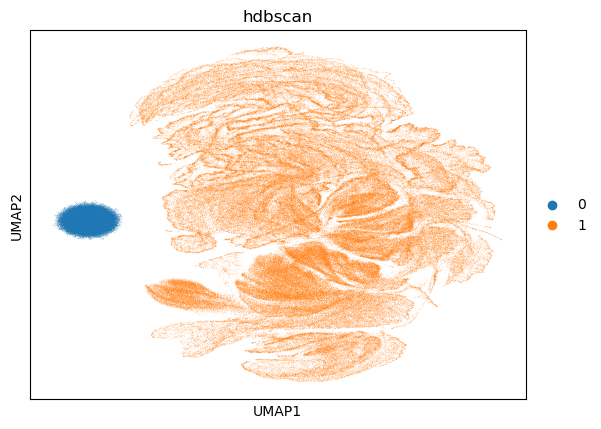

In [49]:
sc.pl.umap(lrdata, color=['hdbscan'])

In [31]:
lrdata.obs["hdbscan"].value_counts()

hdbscan
1    274037
0     93803
Name: count, dtype: int64

/scratch/jobs/38012266/ipykernel_2662515/3791667516.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


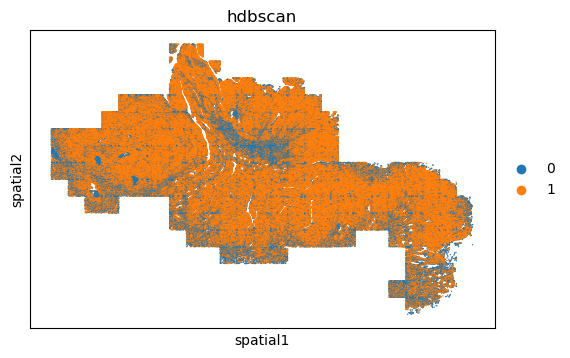

<Figure size 640x480 with 0 Axes>

In [50]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='hdbscan',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

/scratch/jobs/38012266/ipykernel_2662515/1546647171.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


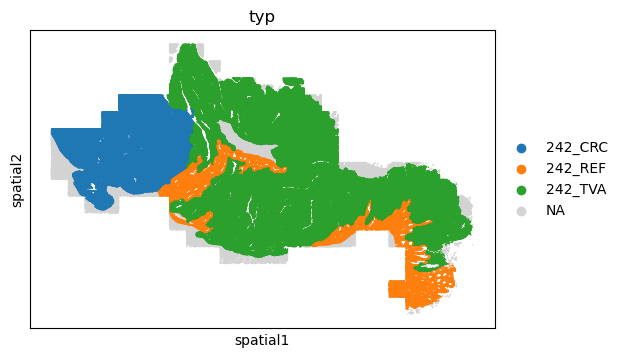

<Figure size 640x480 with 0 Axes>

In [51]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='typ',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

/scratch/jobs/38012266/ipykernel_2662515/2695036056.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


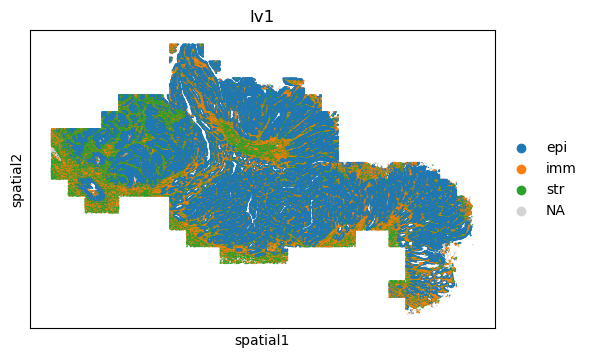

<Figure size 640x480 with 0 Axes>

In [52]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='lv1',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

### ASW

In [ ]:
from scipy.spatial import *
from sklearn.preprocessing import *
from sklearn.metrics import *
from scipy.spatial.distance import *

In [12]:
def compute_ASW(adata, pred_key, spatial_key='spatial'):
    d = squareform(pdist(adata.obsm[spatial_key]))  # pairwise distance matrix
    return silhouette_score(
        X=d,
        labels=adata.obs[pred_key],
        metric='precomputed'
    )

In [17]:
compute_ASW(lrdata, "hdbscan", "spatial")

np.float64(0.004809888410554006)

In [13]:
lrdata_clean = lrdata[~lrdata.obs["typ"].isna()].copy()

In [14]:
compute_ASW(lrdata_clean, "typ", "spatial")

np.float64(0.24550188342705911)

In [15]:
lrdata_clean = lrdata[~lrdata.obs["lv1"].isna()].copy()

In [16]:
compute_ASW(lrdata_clean, "lv1", "spatial")

np.float64(-0.0025489577233897063)

---

### Differential interactions

In [35]:
# Set cluster labels
lrdata.obs['cluster'] = lrdata.obs['hdbscan'].astype(str)

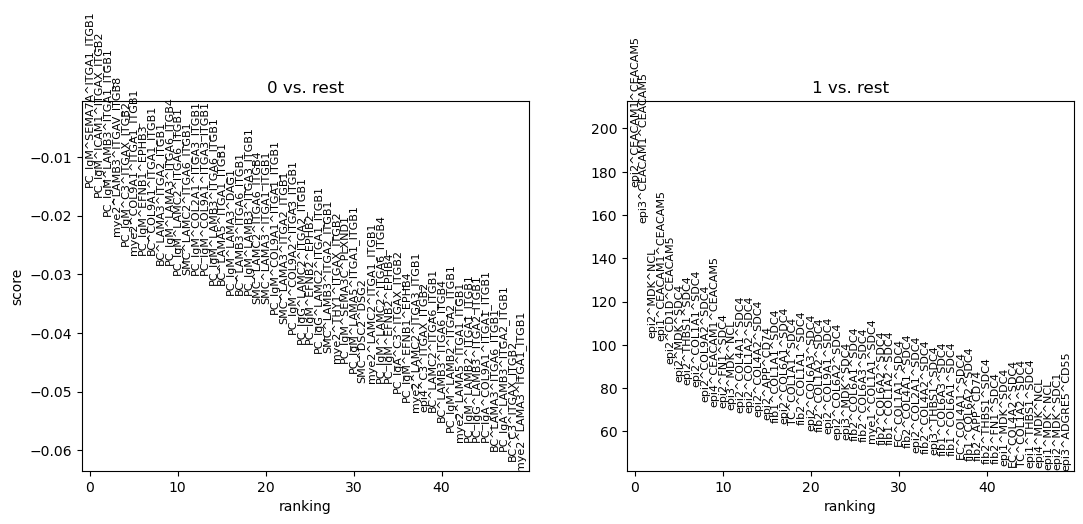

In [36]:
# Run DE test
sc.tl.rank_genes_groups(lrdata, groupby='cluster', method='wilcoxon')
sc.pl.rank_genes_groups(lrdata, n_genes=50, sharey=False)

In [37]:
# Create a dataframe of top-ranked genes
result = lrdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
top_genes = pd.DataFrame(
    {group + '_top': result['names'][group] for group in groups}
)

In [38]:
top_genes.head(10)

,0_top,1_top
0,PC_IgM^SEMA7A^ITGA1_ITGB1,epi2^CEACAM1^CEACAM5
1,PC_IgM^ICAM1^ITGAX_ITGB2,epi3^CEACAM1^CEACAM5
2,PC_IgM^LAMB3^ITGA1_ITGB1,epi2^MDK^NCL
3,mye2^LAMB3^ITGAV_ITGB8,epi1^CEACAM1^CEACAM5
4,PC_IgM^C3^ITGAX_ITGB2,epi2^CD1D^CEACAM5
5,mye2^COL9A1^ITGA1_ITGB1,epi2^MDK^SDC4
6,PC_IgM^EFNB1^EPHB3,epi2^THBS1^SDC4
7,BC^COL9A1^ITGA1_ITGB1,epi2^COL1A1^SDC4
8,BC^LAMA3^ITGA2_ITGB1,epi2^COL9A2^SDC4
9,PC_IgM^LAMA3^ITGA6_ITGB4,epi4^CEACAM1^CEACAM5


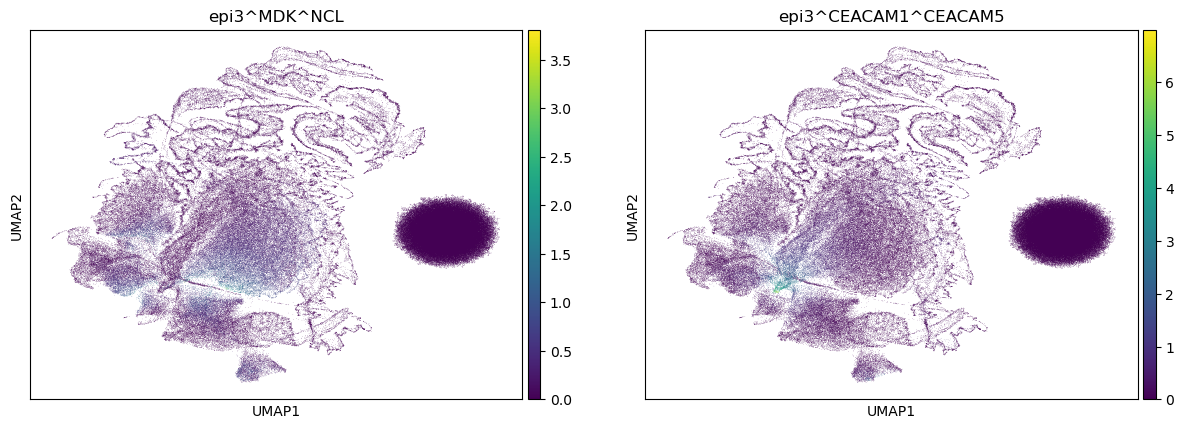

In [15]:
sc.pl.umap(lrdata, color=['epi3^MDK^NCL', 'epi3^CEACAM1^CEACAM5'])

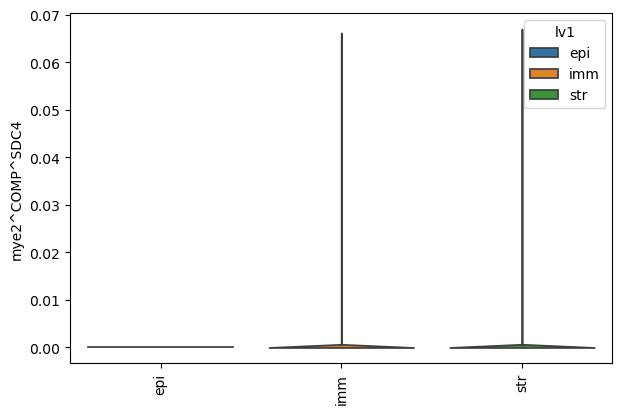

In [29]:
sc.pl.violin(lrdata, keys='mye2^COMP^SDC4', groupby='lv1', stripplot=False, rotation=90)

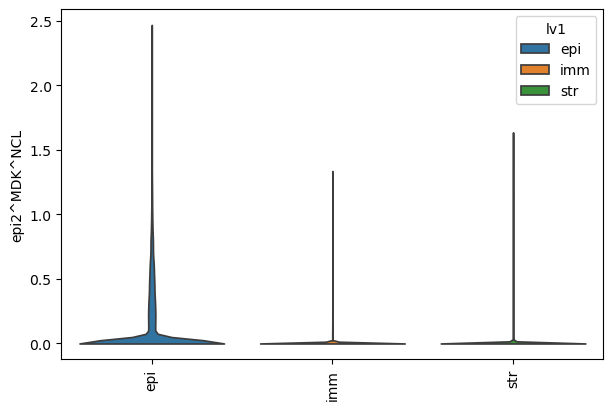

In [28]:
sc.pl.violin(lrdata, keys='epi2^MDK^NCL', groupby='lv1', stripplot=False, rotation=90)

In [17]:
# Combine cell type and cluster into one label
lrdata.obs['lv1_hdb'] = lrdata.obs['lv1'].astype(str) + '_' + lrdata.obs['hdbscan'].astype(str)

In [19]:
top_genes.head(10)

,0_top,1_top
0,epi3^MDK^NCL,SMC^CEACAM1^CEACAM5
1,epi3^CEACAM1^CEACAM5,EC^LAMC2^ITGA6_ITGB4
2,epi2^MDK^NCL,mye2^EFNA1^EPHA2
3,epi4^MDK^NCL,mye2^COL6A3^SDC4
4,epi4^CEACAM1^CEACAM5,mye2^LAMC2^CD44
5,epi2^CEACAM1^CEACAM5,mye2^ADGRE5^CD55
6,epi3^LGALS9^CD44,mye2^COL4A2^SDC4
7,epi3^APP^CD74,mye2^THBS1^SDC4
8,epi3^COL1A1^CD44,mye2^RARRES2^CMKLR2
9,epi2^LGALS9^CD44,mye2^CD46^JAG1


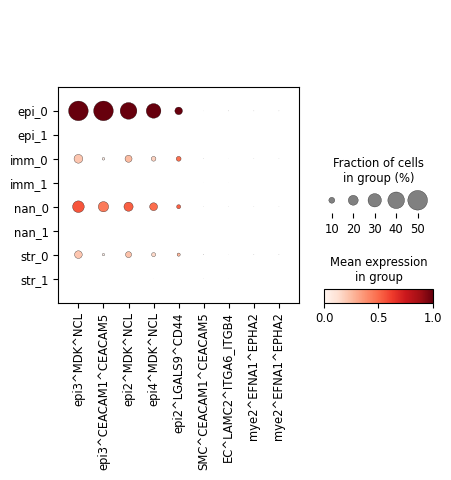

In [21]:
sc.pl.dotplot(lrdata, var_names=['epi3^MDK^NCL', 'epi3^CEACAM1^CEACAM5', 'epi2^MDK^NCL', 'epi4^MDK^NCL', 'epi2^LGALS9^CD44', 'SMC^CEACAM1^CEACAM5', 'EC^LAMC2^ITGA6_ITGB4', 'mye2^EFNA1^EPHA2', 'mye2^EFNA1^EPHA2'], groupby='lv1_hdb', dot_max=0.5, standard_scale='var')

### 4.1 Sender Frequency per Cluster

In [ ]:
import plotly.graph_objects as go

In [80]:
# Parse interaction names
interaction_df = lrdata.var_names.to_series().str.split('^', expand=True)
interaction_df.columns = ['sender', 'ligand', 'receptor']
interaction_df.index = lrdata.var_names

In [97]:
cluster_0_cells = lrdata.obs[lrdata.obs['hdbscan'] == "0"].index
cluster_1_cells = lrdata.obs[lrdata.obs['hdbscan'] == "1"].index

In [99]:
# Get expression matrix
X = lrdata[:, interaction_df.index].X

# If sparse matrix
if not isinstance(X, np.ndarray):
    X = X.toarray()

# Create DataFrames for each cluster
expr_df = pd.DataFrame(X, index=lrdata.obs_names, columns=interaction_df.index)
expr_0 = expr_df.loc[cluster_0_cells].mean(axis=0)
expr_1 = expr_df.loc[cluster_1_cells].mean(axis=0)


In [100]:
# Add back interaction metadata
interaction_df['mean_cluster0'] = expr_0
interaction_df['mean_cluster1'] = expr_1

# Fold change (optional)
interaction_df['log2_fc'] = np.log2((expr_1 + 1e-6) / (expr_0 + 1e-6))

# Top senders
top_senders_cluster1 = (
    interaction_df
    .groupby('sender')['mean_cluster1']
    .sum()
    .sort_values(ascending=False)
)

top_lrp_cluster1 = (
    interaction_df
    .assign(LR=interaction_df['ligand'] + '^' + interaction_df['receptor'])
    .groupby('LR')['mean_cluster1']
    .sum()
    .sort_values(ascending=False)
)

In [142]:
# Melt expression data
melted = expr_df.loc[cluster_1_cells].reset_index().melt(id_vars='index', var_name='interaction', value_name='score')
melted.columns = ['cell', 'interaction', 'score']

In [143]:
# Add metadata
melted = melted.merge(lrdata.obs[['lv2', 'lv1']], left_on='cell', right_index=True)
melted = melted.merge(interaction_df[['sender', 'ligand', 'receptor']], left_on='interaction', right_index=True)

In [144]:
# Make LR
melted['LR'] = melted['ligand'] + '^' + melted['receptor']

In [145]:
melted

,cell,interaction,score,lv2,lv1,sender,ligand,receptor,LR
0,c_3_147_16,epi4^CEACAM1^CEACAM5,0.0,epi.entero,epi,epi4,CEACAM1,CEACAM5,CEACAM1^CEACAM5
1,c_3_147_17,epi4^CEACAM1^CEACAM5,0.0,epi.entero-like_ACSF2,epi,epi4,CEACAM1,CEACAM5,CEACAM1^CEACAM5
2,c_3_147_20,epi4^CEACAM1^CEACAM5,0.0,PC_IgD,imm,epi4,CEACAM1,CEACAM5,CEACAM1^CEACAM5
3,c_3_147_39,epi4^CEACAM1^CEACAM5,0.0,NaN,imm,epi4,CEACAM1,CEACAM5,CEACAM1^CEACAM5
4,c_3_147_50,epi4^CEACAM1^CEACAM5,0.0,epi.entero-like_ACSF2,epi,epi4,CEACAM1,CEACAM5,CEACAM1^CEACAM5
...,...,...,...,...,...,...,...,...,...
40622365,c_3_217_1927,epi2^LAMC2^ITGA6_ITGB4,0.0,epi.goblet-like_REG4,epi,epi2,LAMC2,ITGA6_ITGB4,LAMC2^ITGA6_ITGB4
40622366,c_3_217_1928,epi2^LAMC2^ITGA6_ITGB4,0.0,epi.goblet-like_REG4,epi,epi2,LAMC2,ITGA6_ITGB4,LAMC2^ITGA6_ITGB4
40622367,c_3_217_1931,epi2^LAMC2^ITGA6_ITGB4,0.0,pericytes,str,epi2,LAMC2,ITGA6_ITGB4,LAMC2^ITGA6_ITGB4
40622368,c_3_217_1934,epi2^LAMC2^ITGA6_ITGB4,0.0,epi.prolif_H1,epi,epi2,LAMC2,ITGA6_ITGB4,LAMC2^ITGA6_ITGB4


In [146]:
# Group for Sankey
sankey_df = (
    melted.groupby(['sender', 'LR', 'lv2', 'lv1'])['score']
    .mean()
    .reset_index()
)

/scratch/jobs/38004206/ipykernel_632029/3785690740.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [153]:
sankey_df2 = sankey_df[sankey_df["lv1"] == "str"]

In [154]:
sankey_df2

,sender,LR,lv2,lv1,score
2,EC,APP^CD74,epi.EE,str,NaN
5,EC,APP^CD74,epi.entero,str,NaN
8,EC,APP^CD74,epi.entero-like_ACSF2,str,NaN
11,EC,APP^CD74,epi.fetal-like_EMP1,str,NaN
14,EC,APP^CD74,epi.fetal-like_MMP7,str,NaN
...,...,...,...,...,...
79955,mye2,TNC^SDC4,fib.TLS,str,0.000000
79958,mye2,TNC^SDC4,IAF_MMP,str,0.000000
79961,mye2,TNC^SDC4,LEC,str,0.000000
79964,mye2,TNC^SDC4,pericytes,str,0.000266


In [155]:
# Create list of unique labels
labels = list(pd.unique(sankey_df2['sender'].tolist() + sankey_df2['LR'].tolist() + sankey_df2['lv2'].tolist()))

# Map labels to indices
label2id = {label: i for i, label in enumerate(labels)}

# Build Sankey links
sources = sankey_df2['sender'].map(label2id)
intermediates = sankey_df2['LR'].map(label2id)
targets = sankey_df2['lv2'].map(label2id)
values = sankey_df2['score']

# Create links (sender → LR)
links1 = pd.DataFrame({
    'source': sources,
    'target': intermediates,
    'value': values
})

# Create links (LR → receiver)
links2 = pd.DataFrame({
    'source': intermediates,
    'target': targets,
    'value': values
})
links1 = links1.groupby(['source', 'target'], as_index=False)['value'].sum()
links2 = links2.groupby(['source', 'target'], as_index=False)['value'].sum()


# Combine
links_all = pd.concat([links1, links2], ignore_index=True)

# Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=20, thickness=5),
    link=dict(source=links_all['source'], target=links_all['target'], value=links_all['value'])
)])

fig.update_layout(title_text="Sender → Ligand^Receptor → Receiver (Cluster 0)", font_size=10)
fig.show()

/scratch/jobs/38004206/ipykernel_632029/3598563863.py:2: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.

/scratch/jobs/38004206/ipykernel_632029/3598563863.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### ?

In [1]:
counts = lrdata.obs.groupby(["hdbscan", "typ", "lv1"]).size().reset_index(name="count")

NameError: name 'lrdata' is not defined

In [20]:
# normalize within each cluster (keeps index aligned)
counts["prop"] = counts["count"] / counts.groupby("hdbscan")["count"].transform("sum")

/scratch/jobs/37928731/ipykernel_3732373/97606125.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [21]:
# side-by-side proportions for each (typ, ctx)
pivot = counts.pivot_table(index=["typ", "lv1"], columns="hdbscan", values="prop", fill_value=0)

# difference (cluster 1 minus cluster 0) and sort by strongest enrichment
pivot["diff_1_vs_0"] = pivot.get(1, 0) - pivot.get(0, 0)
pivot

/scratch/jobs/37928731/ipykernel_3732373/2785572891.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


hdbscan             0         1  diff_1_vs_0
typ     lv1                                 
232_CRC epi  0.138030  0.525543            0
        imm  0.163743  0.106232            0
        str  0.343590  0.190573            0
232_REF epi  0.131480  0.094640            0
        imm  0.136230  0.059081            0
        str  0.086928  0.023930            0

In [22]:
adata_epi = lrdata[lrdata.obs["lv1"] == "epi"].copy()

In [23]:
# Run HDBSCAN on the UMAP embedding
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
adata_epi.obs['hdbscan_epi'] = clusterer.fit_predict(adata_epi.obsm['X_umap']).astype(str)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


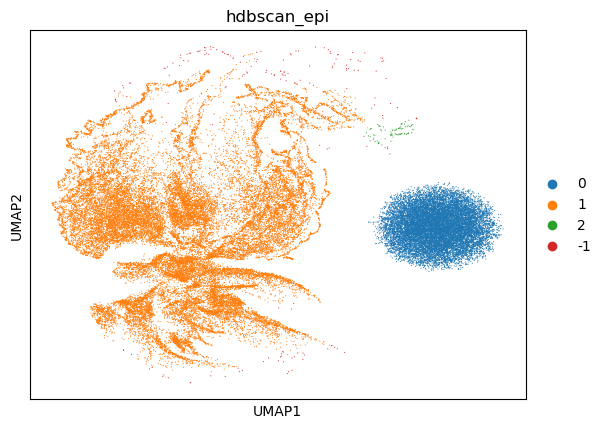

In [24]:
sc.pl.umap(adata_epi, color=['hdbscan_epi'])

In [25]:
adata_epi.obs["hdbscan_epi"].value_counts()

hdbscan_epi
1     34777
0     15191
-1      177
2        84
Name: count, dtype: int64

/scratch/jobs/37928731/ipykernel_3732373/3678762772.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


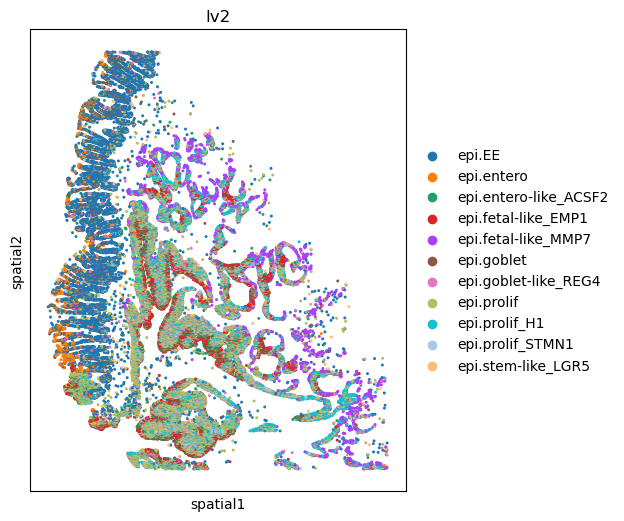

<Figure size 640x480 with 0 Axes>

In [33]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata_epi,
    color='lv2',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

/scratch/jobs/37928731/ipykernel_3732373/2532651461.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


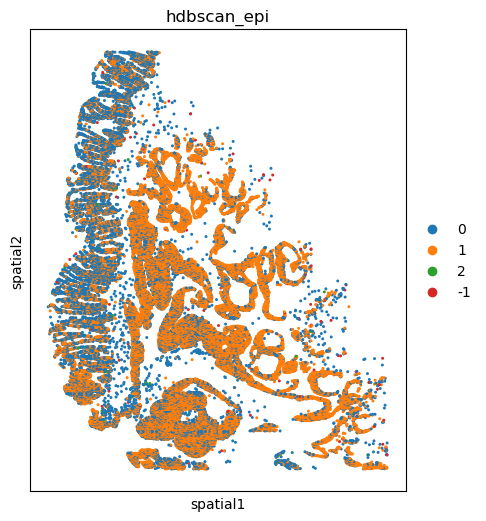

<Figure size 640x480 with 0 Axes>

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata_epi,
    color='hdbscan_epi',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

/scratch/jobs/37928731/ipykernel_3732373/3060057992.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


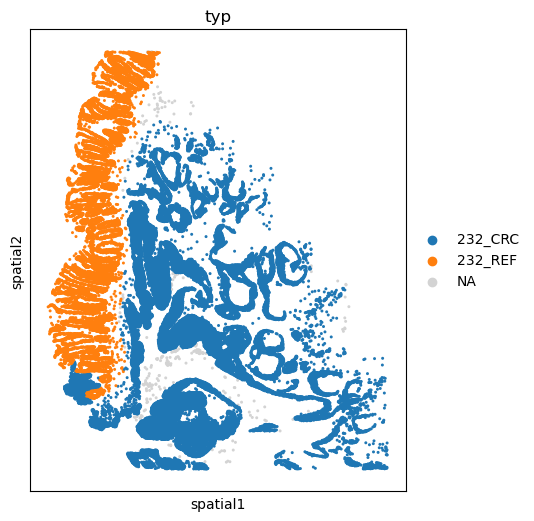

<Figure size 640x480 with 0 Axes>

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata_epi,
    color='typ',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

In [28]:
counts = adata_epi.obs.groupby(["hdbscan_epi", "typ", "lv1"]).size().reset_index(name="count")

/scratch/jobs/37928731/ipykernel_3732373/2795669874.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [29]:
# normalize within each cluster (keeps index aligned)
counts["prop"] = counts["count"] / counts.groupby("hdbscan_epi")["count"].transform("sum")

/scratch/jobs/37928731/ipykernel_3732373/2154146877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [30]:
# side-by-side proportions for each (typ, ctx)
pivot = counts.pivot_table(index=["typ", "lv1"], columns="hdbscan_epi", values="prop", fill_value=0)

# difference (cluster 1 minus cluster 0) and sort by strongest enrichment
pivot["diff_1_vs_0"] = pivot.get(1, 0) - pivot.get(0, 0)
pivot

/scratch/jobs/37928731/ipykernel_3732373/2563348704.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,hdbscan_epi,0,1,2,-1,diff_1_vs_0
typ,lv1,,,,,
232_CRC,epi,0.512151,0.849551,0.4125,0.614035,0
232_REF,epi,0.487849,0.150449,0.5875,0.385965,0


In [31]:
counts = adata_epi.obs.groupby(["hdbscan_epi", "typ", "lv2"]).size().reset_index(name="count")
# normalize within each cluster (keeps index aligned)
counts["prop"] = counts["count"] / counts.groupby("hdbscan_epi")["count"].transform("sum")
# side-by-side proportions for each (typ, ctx)
pivot = counts.pivot_table(index=["typ", "lv2"], columns="hdbscan_epi", values="prop", fill_value=0)

# difference (cluster 1 minus cluster 0) and sort by strongest enrichment
pivot["diff_1_vs_0"] = pivot.get(1, 0) - pivot.get(0, 0)
pivot

/scratch/jobs/37928731/ipykernel_3732373/3995265733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/3995265733.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/3995265733.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


hdbscan_epi                           0         1       2        -1  \
typ     lv2                                                           
232_CRC epi.EE                 0.035853  0.007744  0.0625  0.058480   
        epi.entero             0.002737  0.001411  0.0125  0.000000   
        epi.entero-like_ACSF2  0.047737  0.057577  0.0125  0.029240   
        epi.fetal-like_EMP1    0.066765  0.118494  0.0125  0.011696   
        epi.fetal-like_MMP7    0.035919  0.066991  0.1000  0.228070   
        epi.goblet             0.002404  0.000317  0.0000  0.000000   
        epi.goblet-like_REG4   0.034651  0.046263  0.0500  0.035088   
        epi.prolif             0.138069  0.342354  0.1500  0.181287   
        epi.prolif_H1          0.095407  0.129865  0.0125  0.029240   
        epi.prolif_STMN1       0.032314  0.055994  0.0000  0.011696   
        epi.stem-like_LGR5     0.020296  0.022541  0.0000  0.029240   
232_REF epi.EE                 0.326011  0.109483  0.3625  0.257310   
        epi.entero             0.041261  0.012437  0.0250  0.023392   
        epi.entero-like_ACSF2  0.007544  0.001295  0.0250  0.005848   
        epi.fetal-like_EMP1    0.001135  0.000403  0.0250  0.000000   
        epi.fetal-like_MMP7    0.001135  0.000029  0.0000  0.000000   
        epi.goblet             0.047603  0.012235  0.0625  0.011696   
        epi.goblet-like_REG4   0.013687  0.003138  0.0250  0.011696   
        epi.prolif             0.029844  0.008003  0.0250  0.046784   
        epi.prolif_H1          0.007077  0.001209  0.0000  0.011696   
        epi.prolif_STMN1       0.005475  0.001094  0.0125  0.000000   
        epi.stem-like_LGR5     0.007077  0.001123  0.0250  0.017544   

hdbscan_epi                    diff_1_vs_0  
typ     lv2                                 
232_CRC epi.EE                           0  
        epi.entero                       0  
        epi.entero-like_ACSF2            0  
        epi.fetal-like_EMP1              0  
        epi.fetal-like_MMP7              0  
        epi.goblet                       0  
        epi.goblet-like_REG4             0  
        epi.prolif                       0  
        epi.prolif_H1                    0  
        epi.prolif_STMN1                 0  
        epi.stem-like_LGR5               0  
232_REF epi.EE                           0  
        epi.entero                       0  
        epi.entero-like_ACSF2            0  
        epi.fetal-like_EMP1              0  
        epi.fetal-like_MMP7              0  
        epi.goblet                       0  
        epi.goblet-like_REG4             0  
        epi.prolif                       0  
        epi.prolif_H1                    0  
        epi.prolif_STMN1                 0  
        epi.stem-like_LGR5               0

In [34]:
adata_epi_ee = lrdata[lrdata.obs["lv2"] == "epi.EE"].copy()

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [35]:
# Run HDBSCAN on the UMAP embedding
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
adata_epi_ee.obs['hdbscan_epi_ee'] = clusterer.fit_predict(adata_epi_ee.obsm['X_umap']).astype(str)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


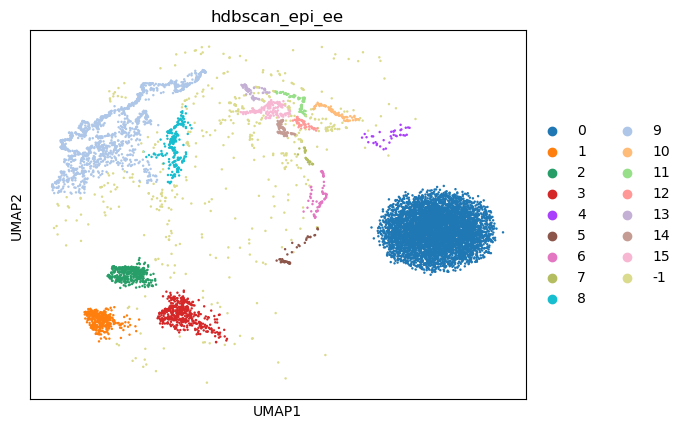

In [36]:
sc.pl.umap(adata_epi_ee, color=['hdbscan_epi_ee'])

In [37]:
adata_epi_ee.obs["hdbscan_epi_ee"].value_counts()

hdbscan_epi_ee
0     5533
9     1403
3      500
-1     475
1      406
2      394
8      236
15     165
14      97
10      90
11      83
13      80
6       68
12      61
5       55
4       36
7       30
Name: count, dtype: int64

/scratch/jobs/37928731/ipykernel_3732373/2125737756.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


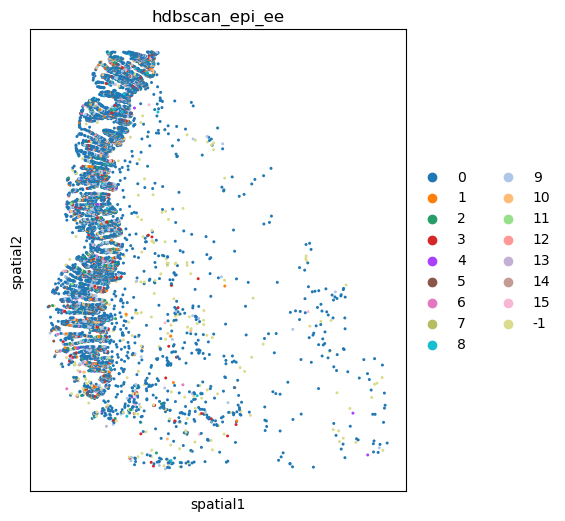

<Figure size 640x480 with 0 Axes>

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata_epi_ee,
    color='hdbscan_epi_ee',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

/scratch/jobs/37928731/ipykernel_3732373/1267455195.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


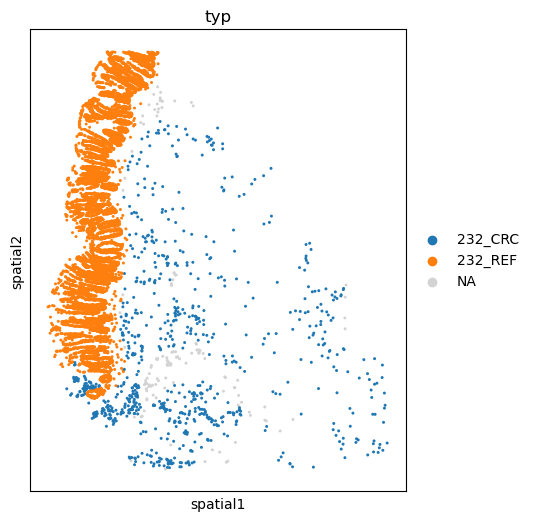

<Figure size 640x480 with 0 Axes>

In [39]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata_epi_ee,
    color='typ',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

In [40]:
counts = adata_epi_ee.obs.groupby(["hdbscan_epi_ee", "typ", "lv1"]).size().reset_index(name="count")
counts["prop"] = counts["count"] / counts.groupby("hdbscan_epi_ee")["count"].transform("sum")
# side-by-side proportions for each (typ, ctx)
pivot = counts.pivot_table(index=["typ", "lv1"], columns="hdbscan_epi_ee", values="prop", fill_value=0)

# difference (cluster 1 minus cluster 0) and sort by strongest enrichment
pivot["diff_1_vs_0"] = pivot.get(1, 0) - pivot.get(0, 0)
pivot

/scratch/jobs/37928731/ipykernel_3732373/3692112781.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/3692112781.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/3692112781.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,hdbscan_epi_ee,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,-1,diff_1_vs_0
typ,lv1,,,,,,,,,,,,,,,,,,
232_CRC,epi,0.099077,0.029777,0.025381,0.042254,0.111111,0.0,0.058824,0.0,0.029787,0.027877,0.044444,0.036145,0.016393,0.0125,0.010309,0.030488,0.367521,0
232_REF,epi,0.900923,0.970223,0.974619,0.957746,0.888889,1.0,0.941176,1.0,0.970213,0.972123,0.955556,0.963855,0.983607,0.9875,0.989691,0.969512,0.632479,0


In [41]:
counts = adata_epi_ee.obs.groupby(["hdbscan_epi_ee", "typ", "lv2"]).size().reset_index(name="count")
counts["prop"] = counts["count"] / counts.groupby("hdbscan_epi_ee")["count"].transform("sum")
# side-by-side proportions for each (typ, ctx)
pivot = counts.pivot_table(index=["typ", "lv2"], columns="hdbscan_epi_ee", values="prop", fill_value=0)

# difference (cluster 1 minus cluster 0) and sort by strongest enrichment
pivot["diff_1_vs_0"] = pivot.get(1, 0) - pivot.get(0, 0)
pivot

/scratch/jobs/37928731/ipykernel_3732373/17806920.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/17806920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/37928731/ipykernel_3732373/17806920.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,hdbscan_epi_ee,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,-1,diff_1_vs_0
typ,lv2,,,,,,,,,,,,,,,,,,
232_CRC,epi.EE,0.099077,0.029777,0.025381,0.042254,0.111111,0.0,0.058824,0.0,0.029787,0.027877,0.044444,0.036145,0.016393,0.0125,0.010309,0.030488,0.367521,0
232_REF,epi.EE,0.900923,0.970223,0.974619,0.957746,0.888889,1.0,0.941176,1.0,0.970213,0.972123,0.955556,0.963855,0.983607,0.9875,0.989691,0.969512,0.632479,0


In [48]:
X = adata_epi.X

In [ ]:
X = X.toarray()

In [62]:
df = pd.DataFrame(
    X,
    index=adata_epi.obs_names,   # cells
    columns=adata_epi.var_names  # genes
)

In [63]:
df

,epi4^CEACAM1^CEACAM5,epi2^CEACAM1^CEACAM5,epi1^CEACAM1^CEACAM5,epi3^CEACAM1^CEACAM5,epi2^MDK^NCL,epi4^MDK^NCL,epi3^MDK^NCL,mye1^CEACAM1^CEACAM5,mye2^CEACAM1^CEACAM5,fib2^CEACAM1^CEACAM5,...,SMC^THBS2^SDC1,epi3^MIF^CD44_CD74,epi1^PDGFA^PDGFRB,epi4^LAMA4^ITGA6_ITGB1,TC^MIF^CD44_CD74,PC_IgM^MDK^ITGA6_ITGB1,PC_IgA^EFNA1^EPHA2,EC^MIF^CD44_CD74,PC_IgA^LAMA4^ITGA6_ITGB1,epi2^LAMC2^ITGA6_ITGB4
c_3_147_2,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_147_3,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_147_11,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_147_16,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.349822,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_147_17,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_217_1925,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_217_1927,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_217_1928,0.278584,0.069655,0.0,0.0,0.0,0.414273,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_3_217_1934,0.000000,0.000000,0.0,0.0,0.0,0.481173,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
clusters_epi = adata_epi.obs["hdbscan_epi"]

In [73]:
clusters_epi

c_3_147_2       0
c_3_147_3       0
c_3_147_11      0
c_3_147_16      1
c_3_147_17      1
               ..
c_3_217_1925    0
c_3_217_1927    1
c_3_217_1928    1
c_3_217_1934    1
c_3_217_1935    1
Name: hdbscan_epi, Length: 50229, dtype: category
Categories (4, object): ['0', '1', '2', '-1']

In [66]:
df =df.T

In [67]:
# Split index into three columns
df[["sender", "ligand", "receptor"]] = df.index.to_series().str.split("^", expand=True)


In [69]:
df

,c_3_147_2,c_3_147_3,c_3_147_11,c_3_147_16,c_3_147_17,c_3_147_18,c_3_147_19,c_3_147_22,c_3_147_26,c_3_147_28,...,c_3_217_1920,c_3_217_1921,c_3_217_1925,c_3_217_1927,c_3_217_1928,c_3_217_1934,c_3_217_1935,sender,ligand,receptor
epi4^CEACAM1^CEACAM5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.172389,0.0,0.0,0.0,0.278584,0.0,0.205931,epi4,CEACAM1,CEACAM5
epi2^CEACAM1^CEACAM5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.094252,0.0,0.0,0.0,0.069655,0.0,0.110885,epi2,CEACAM1,CEACAM5
epi1^CEACAM1^CEACAM5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,epi1,CEACAM1,CEACAM5
epi3^CEACAM1^CEACAM5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,epi3,CEACAM1,CEACAM5
epi2^MDK^NCL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.043742,0.0,0.0,0.0,0.000000,0.0,0.000000,epi2,MDK,NCL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC_IgM^MDK^ITGA6_ITGB1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,PC_IgM,MDK,ITGA6_ITGB1
PC_IgA^EFNA1^EPHA2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,PC_IgA,EFNA1,EPHA2
EC^MIF^CD44_CD74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,EC,MIF,CD44_CD74
PC_IgA^LAMA4^ITGA6_ITGB1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,PC_IgA,LAMA4,ITGA6_ITGB1


In [74]:
# --- 1) Define groups ---
# columns that are actual cells (exclude metadata columns that may exist)
meta_cols = {"sender", "ligand", "receptor", "hdbscan_epi"}
cell_cols = [c for c in df.columns if c not in meta_cols]

In [75]:
# align to clusters index (intersection, preserving df column order)
cell_cols = [c for c in cell_cols if c in clusters_epi.index]

In [76]:
# choose cluster labels robustly (handle category/str/int)
cl_as_str = clusters_epi.astype(str)
cells_pos = [c for c in cell_cols if cl_as_str.loc[c] == "1"]
cells_neg = [c for c in cell_cols if cl_as_str.loc[c] == "0"]

In [ ]:
assert len(cells_pos) > 0, "No cells with cluster == 1 (cells_pos is empty)."
assert len(cells_neg) > 0, "No cells with cluster == 0 (cells_neg is empty)."

In [78]:
# --- 2) Per-feature stats ---
tiny_eps = 1e-9

# Means (vectorized)
mean_pos = df[cells_pos].mean(axis=1)
mean_neg = df[cells_neg].mean(axis=1)

# log2 fold-change
log2FC = np.log2((mean_pos + tiny_eps) / (mean_neg + tiny_eps))

# Mann–Whitney U p-values (row-wise)
def mw_pvalue(row):
    x = row[cells_pos].to_numpy()
    y = row[cells_neg].to_numpy()
    # If both groups constant and equal, return p=1.0 quickly
    if np.all(x == x[0]) and np.all(y == y[0]) and x[0] == y[0]:
        return 1.0
    try:
        return mannwhitneyu(x, y, alternative="two-sided", method="auto").pvalue
    except Exception:
        return np.nan

pvals = df[cell_cols].apply(mw_pvalue, axis=1)

In [80]:
from statsmodels.stats.multitest import multipletests


In [81]:
# Multiple testing correction (FDR, Benjamini–Hochberg)
mask_valid = pvals.notna()
qvals = pd.Series(np.nan, index=df.index)
if mask_valid.any():
    _, q, _, _ = multipletests(pvals[mask_valid].values, alpha=0.05, method="fdr_bh")
    qvals.loc[mask_valid] = q

# --- 3) Rank, assemble, and filter ---
res = pd.DataFrame({
    "feature": df.index,
    "sender": df.get("sender"),
    "ligand": df.get("ligand"),
    "receptor": df.get("receptor"),
    "mean_pos": mean_pos,
    "mean_neg": mean_neg,
    "log2FC": log2FC,
    "q_value": qvals
}).set_index("feature")

res_sorted = res.sort_values(["q_value", "log2FC"], ascending=[True, False])

# Example cutoffs
q_cut = 0.05
fc_cut = 0.5
top_features = res_sorted.loc[(res_sorted["q_value"] <= q_cut) & (res_sorted["log2FC"] >= fc_cut)]


In [82]:
top_features

,sender,ligand,receptor,mean_pos,mean_neg,log2FC,q_value
feature,,,,,,,
epi2^MDK^NCL,epi2,MDK,NCL,0.186042,0.0,27.471056,0.000000
epi4^MDK^NCL,epi4,MDK,NCL,0.124354,0.0,26.889883,0.000000
epi1^CEACAM1^CEACAM5,epi1,CEACAM1,CEACAM5,0.117087,0.0,26.803009,0.000000
epi2^CEACAM1^CEACAM5,epi2,CEACAM1,CEACAM5,0.117071,0.0,26.802814,0.000000
epi4^CEACAM1^CEACAM5,epi4,CEACAM1,CEACAM5,0.116336,0.0,26.793721,0.000000
...,...,...,...,...,...,...,...
SMC^PDGFA^PDGFRB,SMC,PDGFA,PDGFRB,0.000029,0.0,14.843040,0.028908
mye2^TNC^SDC4,mye2,TNC,SDC4,0.000018,0.0,14.148201,0.037195
mye2^COL4A1^SDC1,mye2,COL4A1,SDC1,0.000017,0.0,14.040731,0.037195


In [83]:
# --- Aggregate across senders ---
agg = (
    res
    .groupby(["ligand", "receptor"])
    .agg(
        mean_log2FC=("log2FC", "mean"),
        min_q=("q_value", "min"),
        n_senders=("sender", "nunique")
    )
    .reset_index()
)

# --- Rank LR pairs ---
agg_sorted = agg.sort_values(
    ["mean_log2FC", "min_q"],
    ascending=[False, True]
)

# Example cutoffs
q_cut = 0.05
fc_cut = 0.5
top_lr_pairs = agg_sorted.loc[
    (agg_sorted["min_q"] <= q_cut) & (agg_sorted["mean_log2FC"] >= fc_cut)
]

# peek
# agg_sorted.head(20)
# top_lr_pairs.head(20)

In [84]:
agg_sorted

,ligand,receptor,mean_log2FC,min_q,n_senders
4,COL1A1,SDC4,22.611860,0.000000e+00,14
3,COL1A1,SDC1,22.116438,0.000000e+00,14
2,COL1A1,CD44,22.026744,0.000000e+00,14
29,FN1,SDC4,21.493488,0.000000e+00,14
0,APP,CD74,21.316194,0.000000e+00,14
7,COL1A2,SDC4,21.147386,2.762987e-301,14
28,FN1,SDC1,21.071980,2.469560e-307,14
48,THBS1,CD47,21.069591,0.000000e+00,14
45,MIF,CD44_CD74,21.039921,3.734302e-70,9
40,LGALS9,CD44,20.929722,0.000000e+00,14


In [86]:
# --- Parameters ---
K = 30   # top N LR pairs to analyze
top_lr = agg_sorted.head(K)[["ligand", "receptor"]]

# cluster-1 cells only
cells_pos = clusters_epi[clusters_epi.astype(str) == "1"].index

# --- Sender decomposition ---
results = {}

for _, row in top_lr.iterrows():
    L, R = row["ligand"], row["receptor"]

    # subset rows matching this LR pair
    subset = df[(df["ligand"] == L) & (df["receptor"] == R)]

    # inflow in cluster-1 cells
    inflow = subset[cells_pos]

    # sum inflow per sender
    inflow_by_sender = inflow.groupby(subset["sender"]).sum().sum(axis=1)

    # compute fractions
    fractions = inflow_by_sender / inflow_by_sender.sum()

    results[(L, R)] = fractions.sort_values(ascending=False)

# Example: inspect one LR pair
for lr, frac in results.items():
    print(f"\nSender composition for {lr}:")
    print((frac * 100).round(1).astype(str) + "%")



Sender composition for ('COL1A1', 'SDC4'):
sender
fib2      43.8%
fib1      15.1%
epi4      10.9%
epi2       9.5%
mye1       6.5%
EC         4.3%
epi1       4.0%
PC_IgG     2.7%
epi3       1.2%
TC         0.7%
PC_IgA     0.6%
SMC        0.4%
PC_IgM     0.2%
mye2       0.1%
dtype: object

Sender composition for ('COL1A1', 'SDC1'):
sender
fib2      39.7%
fib1      14.2%
epi2      12.4%
epi4      10.7%
epi1       5.8%
mye1       5.8%
EC         4.5%
PC_IgG     3.1%
epi3       1.6%
PC_IgA     0.8%
TC         0.7%
SMC        0.4%
PC_IgM     0.2%
mye2       0.1%
dtype: object

Sender composition for ('COL1A1', 'CD44'):
sender
fib2      40.0%
fib1      15.4%
epi2      12.8%
epi4       9.5%
mye1       6.1%
epi1       4.8%
EC         4.7%
PC_IgG     3.1%
epi3       1.5%
PC_IgA     0.7%
TC         0.7%
SMC        0.4%
PC_IgM     0.2%
mye2       0.2%
dtype: object

Sender composition for ('FN1', 'SDC4'):
sender
fib2      47.2%
epi2      10.7%
fib1      10.7%
mye1       8.3%
epi4       7.0%
epi1 

In [90]:
# --- 1) Get cluster groups ---
cells_pos = clusters_epi[clusters_epi.astype(str) == "1"].index  # epi-cluster1 cells
cells_neg = clusters_epi[clusters_epi.astype(str) == "0"].index  # epi-cluster0 cells

# --- 2) Extract receptor expression ---
# Assume df has genes as columns and receptors are identified in df["receptor"] column
# If instead receptors are gene names in df.columns, adapt accordingly.

# Let's build a per-receptor gene-level expression table:
receptor_genes = df["receptor"].unique()   # list of receptor names in your feature index

stats_list = []
tiny_eps = 1e-9

for rec in receptor_genes:
    # pick all rows with this receptor (could be multiple ligands/senders)
    sub = df[df["receptor"] == rec]

    # aggregate inflow across all senders/ligands for this receptor
    expr_pos = sub[cells_pos].sum(axis=0)   # per-cell inflow in cluster1
    expr_neg = sub[cells_neg].sum(axis=0)   # per-cell inflow in cluster0

    # means
    mean_pos = expr_pos.mean()
    mean_neg = expr_neg.mean()

    # log2FC
    log2fc = np.log2((mean_pos + tiny_eps) / (mean_neg + tiny_eps))

    # Mann–Whitney U test
    try:
        pval = mannwhitneyu(expr_pos, expr_neg, alternative="two-sided", method="auto").pvalue
    except Exception:
        pval = np.nan

    stats_list.append({
        "receptor": rec,
        "mean_pos": mean_pos,
        "mean_neg": mean_neg,
        "log2FC": log2fc,
        "p_value": pval
    })

# --- 3) Multiple test correction ---
res_receptors = pd.DataFrame(stats_list).set_index("receptor")
mask_valid = res_receptors["p_value"].notna()
qvals = pd.Series(np.nan, index=res_receptors.index)

if mask_valid.any():
    _, q, _, _ = multipletests(res_receptors.loc[mask_valid, "p_value"], method="fdr_bh")
    qvals.loc[mask_valid] = q

res_receptors["q_value"] = qvals

# --- 4) Rank and filter ---
res_receptors = res_receptors.sort_values(["q_value", "log2FC"], ascending=[True, False])

# Example cutoffs
top_receptors = res_receptors.query("q_value <= 0.05 and log2FC >= 0.5")

In [91]:
top_receptors

,mean_pos,mean_neg,log2FC,p_value,q_value
receptor,,,,,
SDC4,1.138306,0.000000,30.084241,0.000000e+00,0.000000e+00
SDC1,0.786284,0.000000,29.550476,0.000000e+00,0.000000e+00
CD44,0.746735,0.000000,29.476022,0.000000e+00,0.000000e+00
CD74,0.184442,0.000000,27.458592,0.000000e+00,0.000000e+00
CD47,0.171435,0.000000,27.353089,0.000000e+00,0.000000e+00
EPHA2,0.030395,0.000002,13.579128,0.000000e+00,0.000000e+00
NCL,0.447621,0.000038,13.508019,0.000000e+00,0.000000e+00
TGFBR2,0.108055,0.000011,13.203712,0.000000e+00,0.000000e+00
CEACAM5,0.407559,0.000078,12.342078,0.000000e+00,0.000000e+00
